# Alzheimer's Disease Stage Classification from Brain MRI Images

Classification of Alzheimer's disease stages from MRI brain scans using deep learning.  
Four classes: **NonDemented**, **VeryMildDemented**, **MildDemented**, **ModerateDemented**.

## 1. Imports and Setup

In [1]:
import copy
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
from tqdm.notebook import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 1337


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Favor repeatable results over maximum cuDNN performance.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed: {RANDOM_STATE}")

Device: cpu
PyTorch version: 2.13.0+cpu
Random seed: 1337


## 2. Helper Functions

In [2]:
def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def bind_gpu(data):
    dev = get_device()
    if isinstance(data, (list, tuple)):
        return [bind_gpu(d) for d in data]
    return data.to(dev, non_blocking=True)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    for name, layer in model.named_children():
        n = sum(p.numel() for p in layer.parameters())
        print(f"Layer: {name}, Parameters: {n}")
    print(f"Total parameters: {total}")
    return total


def train_model(
    model,
    criterion,
    optimizer,
    num_epochs,
    train_loader,
    val_loader,
    patience=5,
    model_name='Model'
):
    metrics = {
        'epoch': [],
        'train_loss': [], 'train_accuracy': [],
        'val_loss': [], 'val_accuracy': [],
    }

    dev = get_device()
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0

    pbar = tqdm(range(1, num_epochs + 1), desc=f'{model_name} progress')
    for epoch in pbar:
        pbar.set_description(f'{model_name} | Epoch {epoch}/{num_epochs}')
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_batches = tqdm(
            train_loader,
            desc=f'Training epoch {epoch}/{num_epochs}',
            leave=False
        )
        for inputs, labels in train_batches:
            inputs = inputs.to(dev, non_blocking=True)
            labels = labels.to(dev, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            probabilities, logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            train_loss += loss.item() * batch_size
            train_correct += (torch.argmax(probabilities, dim=1) == labels).sum().item()
            train_total += batch_size
            train_batches.set_postfix({'batch_loss': f'{loss.item():.4f}'})

        train_loss /= train_total
        train_accuracy = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            validation_batches = tqdm(
                val_loader,
                desc=f'Validation epoch {epoch}/{num_epochs}',
                leave=False
            )
            for inputs, labels in validation_batches:
                inputs = inputs.to(dev, non_blocking=True)
                labels = labels.to(dev, non_blocking=True)
                probabilities, logits = model(inputs)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                val_loss += loss.item() * batch_size
                val_correct += (torch.argmax(probabilities, dim=1) == labels).sum().item()
                val_total += batch_size

        val_loss /= val_total
        val_accuracy = val_correct / val_total

        metrics['epoch'].append(epoch)
        metrics['train_loss'].append(train_loss)
        metrics['train_accuracy'].append(train_accuracy)
        metrics['val_loss'].append(val_loss)
        metrics['val_accuracy'].append(val_accuracy)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        pbar.set_postfix({
            'train_loss': f'{train_loss:.4f}',
            'val_loss': f'{val_loss:.4f}',
            'val_acc': f'{val_accuracy:.4f}',
        })

        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    print(f"Best epoch: {best_epoch} (validation loss: {best_val_loss:.4f})")
    return metrics


def plot_metrics(metrics, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)

    axes[0].plot(metrics['epoch'], metrics['train_loss'], label='Train Loss')
    axes[0].plot(metrics['epoch'], metrics['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(metrics['epoch'], metrics['train_accuracy'], label='Train Accuracy')
    axes[1].plot(metrics['epoch'], metrics['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


CLASS_NAMES = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']


def evaluate_model(model, criterion, dataloader, title=''):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    predicted_labels = []
    true_labels = []
    dev = get_device()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(dev, non_blocking=True)
            labels = labels.to(dev, non_blocking=True)
            probabilities, logits = model(inputs)

            batch_size = labels.size(0)
            total_loss += criterion(logits, labels).item() * batch_size
            total_samples += batch_size

            predicted = torch.argmax(probabilities, dim=1)
            predicted_labels.extend(predicted.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    loss = total_loss / total_samples
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average='weighted',
        zero_division=0
    )

    print(title)
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1_score:.4f}")

    cm = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=range(len(CLASS_NAMES))
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return {
        'loss': loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'true_labels': true_labels,
        'predicted_labels': predicted_labels,
    }


print("Helper functions defined.")

Helper functions defined.


## 3. Data Loading and Exploratory Data Analysis

In [3]:
DATA_DIR = Path("Alzheimer_s Dataset/data")

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

image_paths, labels = [], []
for class_name, class_idx in CLASS_TO_IDX.items():
    class_dir = DATA_DIR / class_name
    for img_path in sorted(class_dir.iterdir()):
        image_paths.append(img_path)
        labels.append(class_idx)

print(f"Total images: {len(image_paths)}")
counts = Counter(labels)
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {counts[idx]}")

Total images: 6400
  NonDemented: 3200
  VeryMildDemented: 2240
  MildDemented: 896
  ModerateDemented: 64


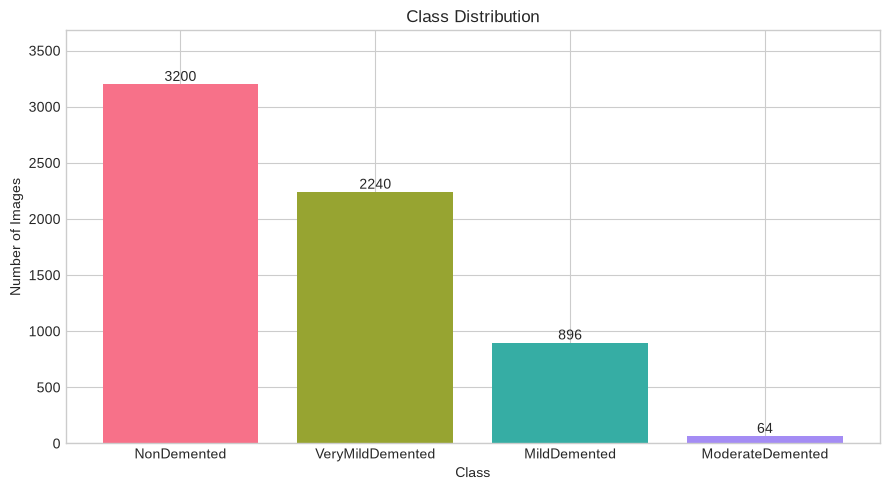

In [4]:
class_counts = [counts[i] for i in range(4)]
colors = sns.color_palette('husl', 4)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, class_counts, color=colors)

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha='center')

ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, max(class_counts) * 1.15)
plt.tight_layout()
plt.show()

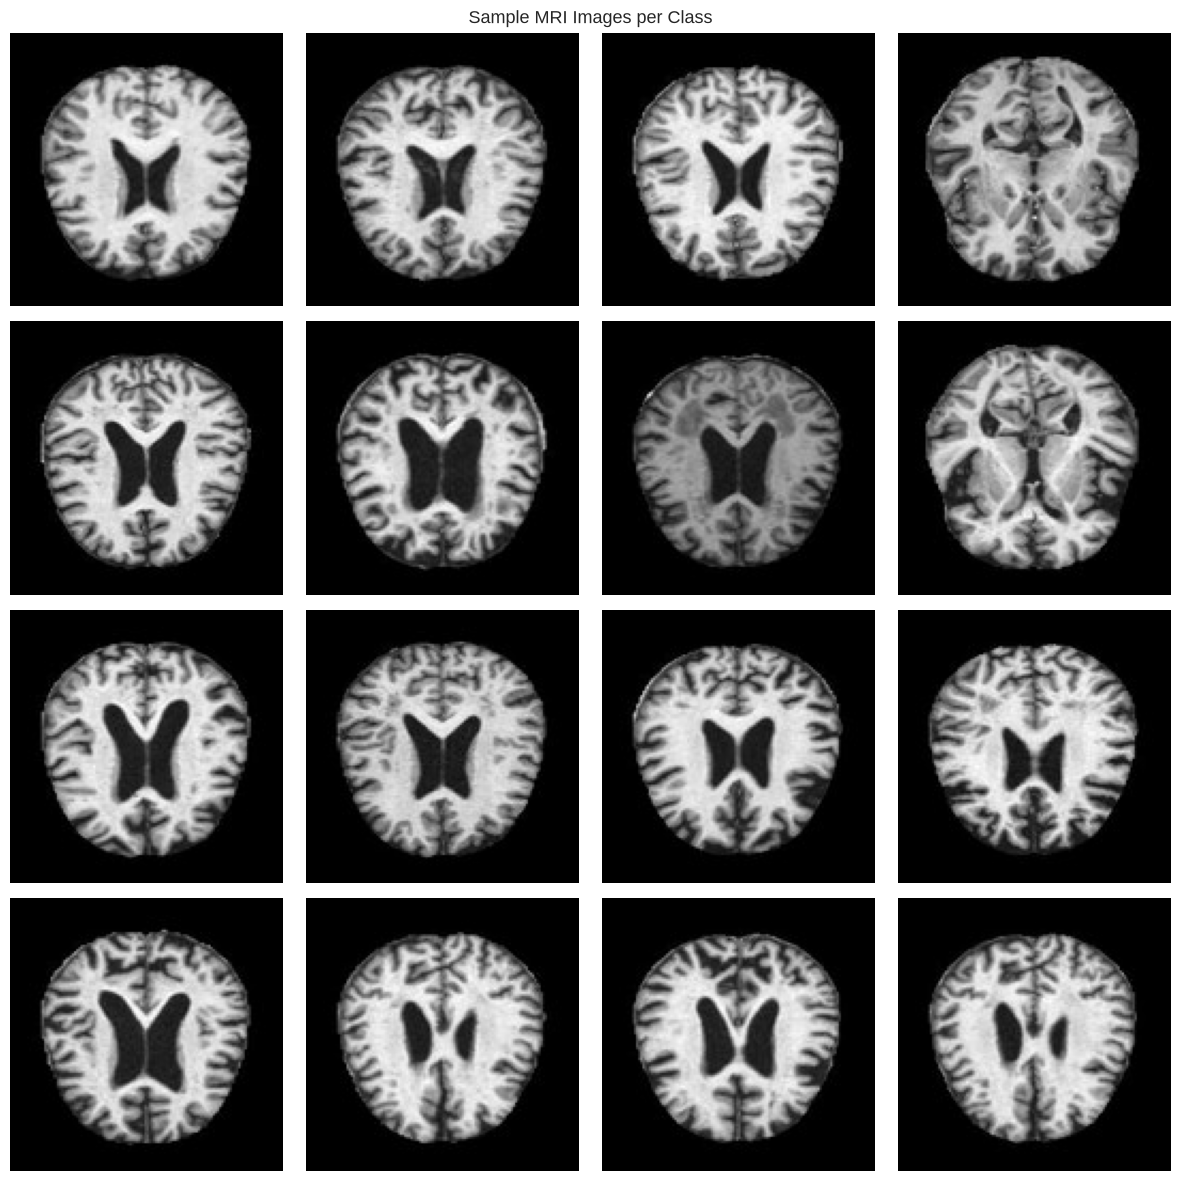

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample MRI Images per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    for col, img_path in enumerate(class_paths[:4]):
        ax = axes[class_idx][col]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_name, fontsize=9, rotation=90, labelpad=10)
            ax.yaxis.set_label_position('left')

plt.tight_layout()
plt.show()

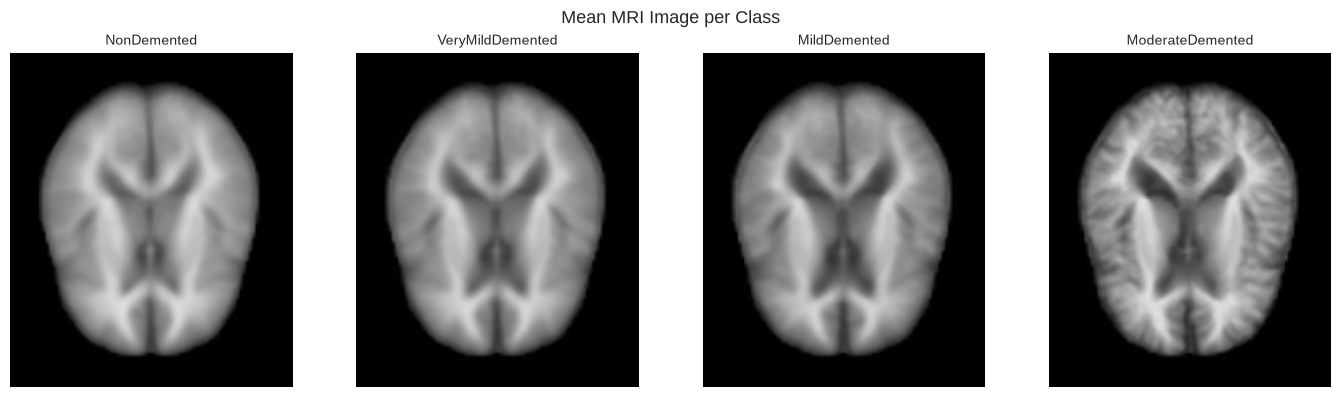

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Mean MRI Image per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    imgs = np.stack([
        np.array(Image.open(p).convert('L').resize((176, 208)), dtype=np.float32)
        for p in class_paths
    ])
    mean_img = imgs.mean(axis=0)
    axes[class_idx].imshow(mean_img, cmap='gray', vmin=0, vmax=255)
    axes[class_idx].set_title(class_name, fontsize=10)
    axes[class_idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Train, Validation and Test Split

The original images are split before augmentation. The validation and test sets therefore remain unchanged and are shared by both CNNs. Stratification preserves the class proportions in each partition.

In [7]:
all_paths = np.array(image_paths, dtype=object)
all_labels = np.array(labels, dtype=np.int64)

train_paths, temporary_paths, train_labels, temporary_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=all_labels
)

validation_paths, test_paths, validation_labels, test_labels = train_test_split(
    temporary_paths,
    temporary_labels,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temporary_labels
)

train_paths, train_labels = list(train_paths), list(train_labels)
validation_paths, validation_labels = list(validation_paths), list(validation_labels)
test_paths, test_labels = list(test_paths), list(test_labels)

print(f"Training images:   {len(train_paths)}")
print(f"Validation images: {len(validation_paths)}")
print(f"Test images:       {len(test_paths)}")

Training images:   4480
Validation images: 960
Test images:       960


Split,Training,Validation,Test
Class,,,
NonDemented,2240,480,480
VeryMildDemented,1568,336,336
MildDemented,627,135,134
ModerateDemented,45,9,10


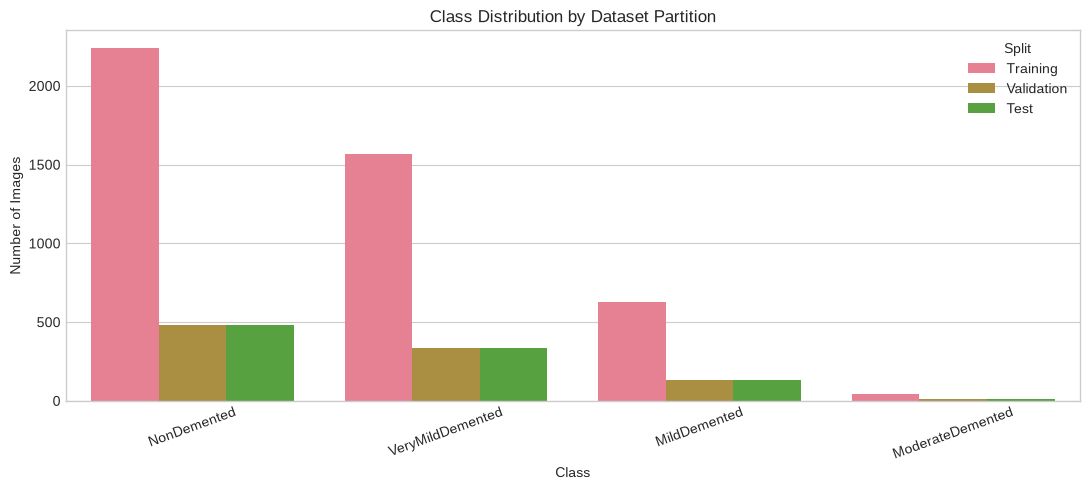

In [8]:
split_records = []
for split_name, split_labels in [
    ('Training', train_labels),
    ('Validation', validation_labels),
    ('Test', test_labels),
]:
    split_counts = Counter(split_labels)
    for class_index, class_name in enumerate(CLASS_NAMES):
        split_records.append({
            'Split': split_name,
            'Class': class_name,
            'Count': split_counts[class_index],
        })

split_distribution = pd.DataFrame(split_records)
split_table = split_distribution.pivot(index='Class', columns='Split', values='Count')
split_table = split_table.loc[CLASS_NAMES, ['Training', 'Validation', 'Test']]
display(split_table)

plt.figure(figsize=(11, 5))
sns.barplot(data=split_distribution, x='Class', y='Count', hue='Split')
plt.title('Class Distribution by Dataset Partition')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Dataset Preparation and Training-Only Augmentation

Normalization statistics are calculated using only the training partition. The first CNN uses the original training images. For the second CNN, additional transformed copies are created dynamically from training images until every class has the same number of samples as the largest training class.

No validation or test image is augmented or included in either training dataset.

In [9]:
pixel_sum = 0.0
pixel_squared_sum = 0.0
pixel_count = 0

for img_path in tqdm(train_paths, desc='Calculating normalization statistics'):
    pixels = np.asarray(Image.open(img_path).convert('L'), dtype=np.float64) / 255.0
    pixel_sum += pixels.sum()
    pixel_squared_sum += np.square(pixels).sum()
    pixel_count += pixels.size

TRAIN_MEAN = pixel_sum / pixel_count
TRAIN_VARIANCE = pixel_squared_sum / pixel_count - TRAIN_MEAN ** 2
TRAIN_STD = np.sqrt(max(TRAIN_VARIANCE, 1e-12))

print(f"Training mean: {TRAIN_MEAN:.6f}")
print(f"Training standard deviation: {TRAIN_STD:.6f}")

Calculating normalization statistics:   0%|          | 0/4480 [00:00<?, ?it/s]

Training mean: 0.278305
Training standard deviation: 0.326418


In [10]:
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

augmentation_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])


class MRIDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index]).convert('L')
        image = self.transform(image)
        label = int(self.labels[index])
        return image, label


class BalancedAugmentedMRIDataset(Dataset):
    def __init__(
        self,
        paths,
        labels,
        original_transform,
        augmented_transform,
        random_state=RANDOM_STATE
    ):
        self.original_transform = original_transform
        self.augmented_transform = augmented_transform
        self.samples = [
            (path, int(label), False)
            for path, label in zip(paths, labels)
        ]

        rng = np.random.default_rng(random_state)
        class_counts = Counter(int(label) for label in labels)
        target_count = max(class_counts.values())

        for class_index in range(len(CLASS_NAMES)):
            class_paths = [
                path for path, label in zip(paths, labels)
                if int(label) == class_index
            ]
            additional_count = target_count - len(class_paths)

            for _ in range(additional_count):
                selected_index = rng.integers(0, len(class_paths))
                self.samples.append((class_paths[selected_index], class_index, True))

        rng.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label, should_augment = self.samples[index]
        image = Image.open(path).convert('L')
        transform = self.augmented_transform if should_augment else self.original_transform
        image = transform(image)
        return image, label


original_train_dataset = MRIDataset(train_paths, train_labels, base_transform)
augmented_train_dataset = BalancedAugmentedMRIDataset(
    train_paths,
    train_labels,
    base_transform,
    augmentation_transform
)
validation_dataset = MRIDataset(validation_paths, validation_labels, base_transform)
test_dataset = MRIDataset(test_paths, test_labels, base_transform)

print(f"Original training dataset:  {len(original_train_dataset)} images")
print(f"Augmented training dataset: {len(augmented_train_dataset)} images")

Original training dataset:  4480 images
Augmented training dataset: 8960 images


,Class,Original,Augmented
0,NonDemented,2240,2240
1,VeryMildDemented,1568,2240
2,MildDemented,627,2240
3,ModerateDemented,45,2240


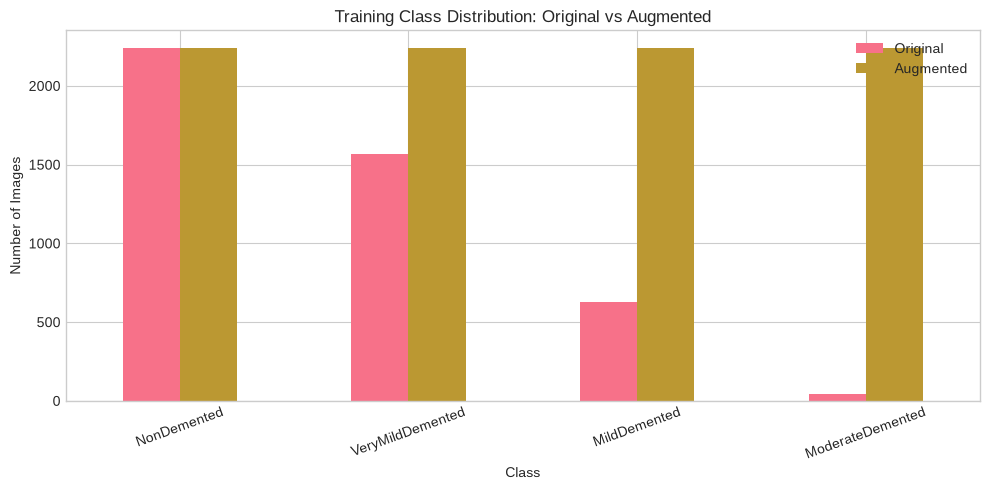

In [11]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


BATCH_SIZE = 64
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

original_generator = torch.Generator().manual_seed(RANDOM_STATE)
augmented_generator = torch.Generator().manual_seed(RANDOM_STATE)

original_train_loader = DataLoader(
    original_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=original_generator,
)
augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=augmented_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
)

augmented_counts = Counter(label for _, label, _ in augmented_train_dataset.samples)
training_distribution = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Original': [Counter(train_labels)[i] for i in range(len(CLASS_NAMES))],
    'Augmented': [augmented_counts[i] for i in range(len(CLASS_NAMES))],
})
display(training_distribution)

training_distribution.set_index('Class').plot(kind='bar', figsize=(10, 5))
plt.title('Training Class Distribution: Original vs Augmented')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

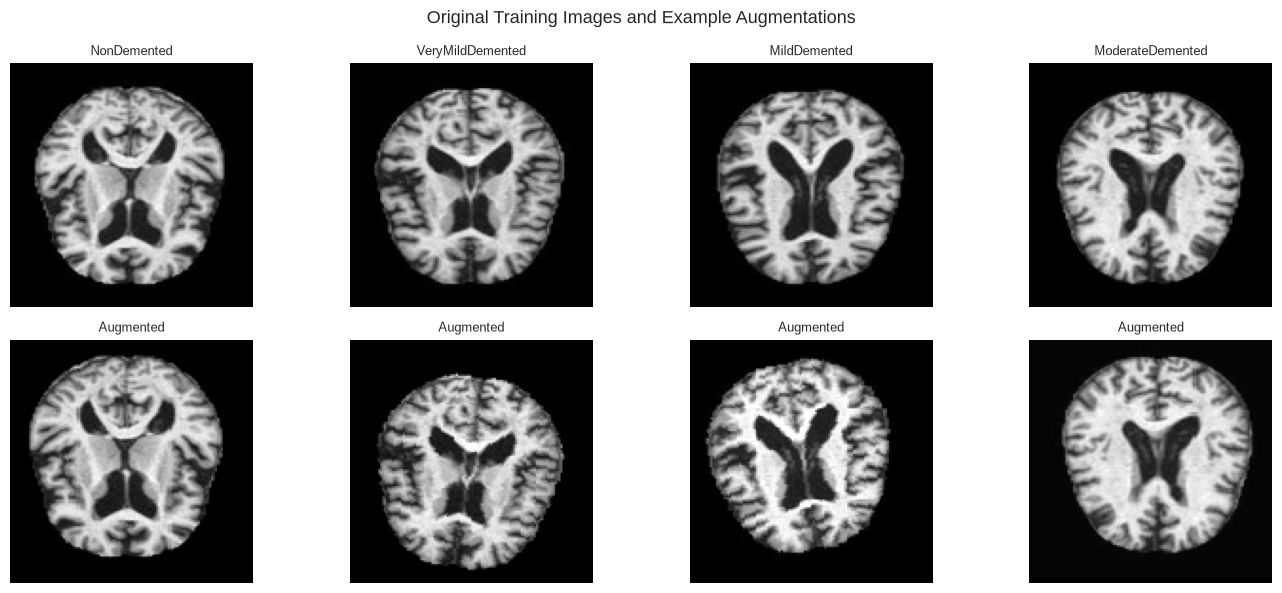

Example input batch shape: torch.Size([64, 1, 128, 128])
Example label batch shape: torch.Size([64])


In [12]:
fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(14, 6))
fig.suptitle('Original Training Images and Example Augmentations', fontsize=13)

for class_index, class_name in enumerate(CLASS_NAMES):
    sample_path = next(
        path for path, label in zip(train_paths, train_labels)
        if label == class_index
    )
    original_image = Image.open(sample_path).convert('L')
    augmented_tensor = augmentation_transform(original_image)
    augmented_image = augmented_tensor.squeeze(0) * TRAIN_STD + TRAIN_MEAN

    axes[0, class_index].imshow(original_image, cmap='gray')
    axes[0, class_index].set_title(class_name, fontsize=9)
    axes[0, class_index].axis('off')

    axes[1, class_index].imshow(augmented_image.clamp(0, 1), cmap='gray')
    axes[1, class_index].set_title('Augmented', fontsize=9)
    axes[1, class_index].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Augmented')
plt.tight_layout()
plt.show()

example_inputs, example_labels = next(iter(original_train_loader))
print(f"Example input batch shape: {example_inputs.shape}")
print(f"Example label batch shape: {example_labels.shape}")

## 6. CNN Architecture

The architecture uses convolution, activation, max pooling, dropout, flattening and fully connected layers. Repeated max pooling gradually reduces the 128×128 feature maps before they are passed to the fully connected layers.

In [13]:
class AlzheimerConvClassifier(nn.Module):
    def __init__(self, number_of_classes):
        super(AlzheimerConvClassifier, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(in_features=64 * 8 * 8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=number_of_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout1(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        logits = self.fc2(x)
        probabilities = F.softmax(logits, dim=1)

        return probabilities, logits

In [14]:
set_seed()
model_example = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)
print(model_example)
count_parameters(model_example)

with torch.no_grad():
    example_probabilities, example_logits = model_example(example_inputs.to(device))

print(f"Logit shape: {example_logits.shape}")
print(f"Probability shape: {example_probabilities.shape}")

AlzheimerConvClassifier(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Layer: conv1, Parameters: 160
Layer: conv2, Parameters: 4640
Layer: conv3, Parameters: 18496
Layer: pool, Parameters: 0
Layer: dropout1, Parameters: 0
Layer: dropout2, Parameters: 0
Layer: fc1, Parameters: 524416
Layer: fc2, Parameters: 516
Total parameters: 548228
Logit shape: torch.Size([64, 4])
Probability shape: torch.Size([64, 4])


## 7. Training Configuration

Both networks use the same architecture, initial parameters, loss function, optimizer settings and early-stopping rule. Only their training datasets differ.

In [15]:
MAX_EPOCHS = 60
LEARNING_RATE = 0.001
PATIENCE = 10
RETRAIN_MODELS = False

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ORIGINAL_MODEL_PATH = MODEL_DIR / 'alzheimer_cnn_non_augmented.pt'
AUGMENTED_MODEL_PATH = MODEL_DIR / 'alzheimer_cnn_augmented.pt'

criterion = nn.CrossEntropyLoss()

set_seed()
initial_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES))
initial_state = copy.deepcopy(initial_model.state_dict())
del initial_model

print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Early-stopping patience: {PATIENCE}")
print(f"Retrain existing models: {RETRAIN_MODELS}")
print(f"Model directory: {MODEL_DIR.resolve()}")

Maximum epochs: 60
Learning rate: 0.001
Early-stopping patience: 10
Retrain existing models: False
Model directory: /home/jovan/University/ML/Deep-Learning-For-Human-Body-Marker-Augmentation/models


## 8. CNN Trained on the Non-Augmented Set

The first CNN is trained only on the original images in the training partition. Its best parameters are selected using validation loss.

In [16]:
set_seed()
original_generator.manual_seed(RANDOM_STATE)
original_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)

if ORIGINAL_MODEL_PATH.exists() and not RETRAIN_MODELS:
    checkpoint = torch.load(ORIGINAL_MODEL_PATH, map_location=device)
    original_model.load_state_dict(checkpoint['model_state_dict'])
    original_metrics = checkpoint['metrics']
    print(f"Loaded non-augmented model from {ORIGINAL_MODEL_PATH}")
else:
    original_model.load_state_dict(initial_state)
    original_optimizer = optim.Adam(original_model.parameters(), lr=LEARNING_RATE)
    original_metrics = train_model(
        original_model,
        criterion,
        original_optimizer,
        MAX_EPOCHS,
        original_train_loader,
        validation_loader,
        patience=PATIENCE,
        model_name='Non-Augmented CNN'
    )
    torch.save(
        {
            'model_state_dict': original_model.state_dict(),
            'metrics': original_metrics,
            'class_names': CLASS_NAMES,
            'train_mean': float(TRAIN_MEAN),
            'train_std': float(TRAIN_STD),
            'random_state': RANDOM_STATE,
        },
        ORIGINAL_MODEL_PATH
    )
    print(f"Saved non-augmented model to {ORIGINAL_MODEL_PATH}")

Non-Augmented CNN progress:   0%|          | 0/60 [00:00<?, ?it/s]

Training epoch 1/60:   0%|          | 0/70 [00:00<?, ?it/s]

Validation epoch 1/60:   0%|          | 0/15 [00:00<?, ?it/s]

Training epoch 2/60:   0%|          | 0/70 [00:00<?, ?it/s]

Validation epoch 2/60:   0%|          | 0/15 [00:00<?, ?it/s]

...

Training epoch 52/60:   0%|          | 0/70 [00:00<?, ?it/s]

Validation epoch 52/60:   0%|          | 0/15 [00:00<?, ?it/s]

Training epoch 53/60:   0%|          | 0/70 [00:00<?, ?it/s]

Validation epoch 53/60:   0%|          | 0/15 [00:00<?, ?it/s]

Early stopping after epoch 53.
Best epoch: 43 (validation loss: 0.1178)
Saved non-augmented model to models/alzheimer_cnn_non_augmented.pt


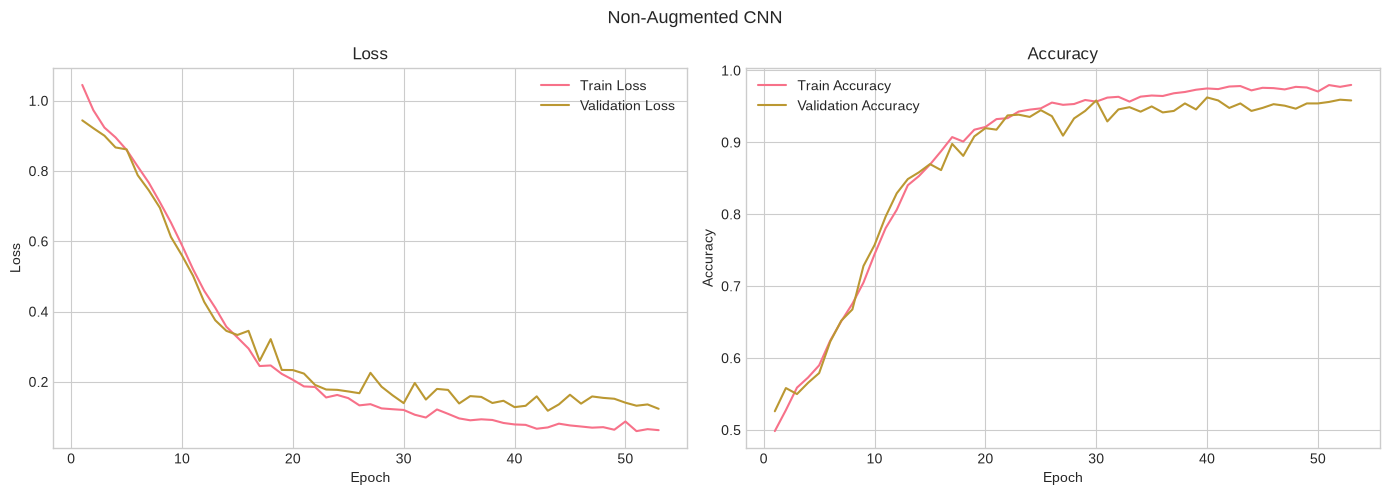

In [17]:
plot_metrics(original_metrics, title='Non-Augmented CNN')

## 9. CNN Trained on the Augmented Set

The second CNN starts from the same initial parameters and is trained on the balanced training-only augmented dataset. The validation set is identical to the one used for the first CNN.

In [18]:
set_seed()
augmented_generator.manual_seed(RANDOM_STATE)
augmented_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)

if AUGMENTED_MODEL_PATH.exists() and not RETRAIN_MODELS:
    checkpoint = torch.load(AUGMENTED_MODEL_PATH, map_location=device)
    augmented_model.load_state_dict(checkpoint['model_state_dict'])
    augmented_metrics = checkpoint['metrics']
    print(f"Loaded augmented model from {AUGMENTED_MODEL_PATH}")
else:
    augmented_model.load_state_dict(initial_state)
    augmented_optimizer = optim.Adam(augmented_model.parameters(), lr=LEARNING_RATE)
    augmented_metrics = train_model(
        augmented_model,
        criterion,
        augmented_optimizer,
        MAX_EPOCHS,
        augmented_train_loader,
        validation_loader,
        patience=PATIENCE,
        model_name='Augmented CNN'
    )
    torch.save(
        {
            'model_state_dict': augmented_model.state_dict(),
            'metrics': augmented_metrics,
            'class_names': CLASS_NAMES,
            'train_mean': float(TRAIN_MEAN),
            'train_std': float(TRAIN_STD),
            'random_state': RANDOM_STATE,
        },
        AUGMENTED_MODEL_PATH
    )
    print(f"Saved augmented model to {AUGMENTED_MODEL_PATH}")

Augmented CNN progress:   0%|          | 0/60 [00:00<?, ?it/s]

Training epoch 1/60:   0%|          | 0/140 [00:00<?, ?it/s]

Validation epoch 1/60:   0%|          | 0/15 [00:00<?, ?it/s]

Training epoch 2/60:   0%|          | 0/140 [00:00<?, ?it/s]

Validation epoch 2/60:   0%|          | 0/15 [00:00<?, ?it/s]

...

Training epoch 59/60:   0%|          | 0/140 [00:00<?, ?it/s]

Validation epoch 59/60:   0%|          | 0/15 [00:00<?, ?it/s]

Training epoch 60/60:   0%|          | 0/140 [00:00<?, ?it/s]

Validation epoch 60/60:   0%|          | 0/15 [00:00<?, ?it/s]

Best epoch: 58 (validation loss: 0.1539)
Saved augmented model to models/alzheimer_cnn_augmented.pt


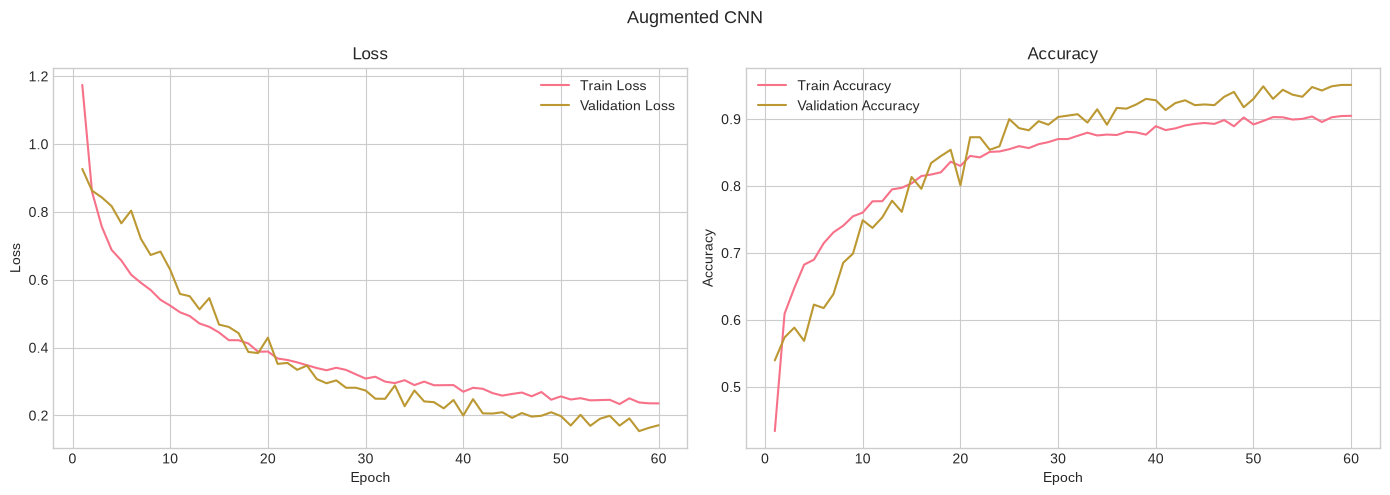

In [19]:
plot_metrics(augmented_metrics, title='Augmented CNN')

## 10. Test-Set Evaluation

The final models are evaluated on the same untouched test set. Following the course notebook, the reported metrics are loss, accuracy, weighted precision, weighted recall, weighted F1 score and the confusion matrix.

Non-Augmented CNN
Loss     : 0.1094
Accuracy : 0.9563
Precision: 0.9569
Recall   : 0.9563
F1 Score : 0.9560


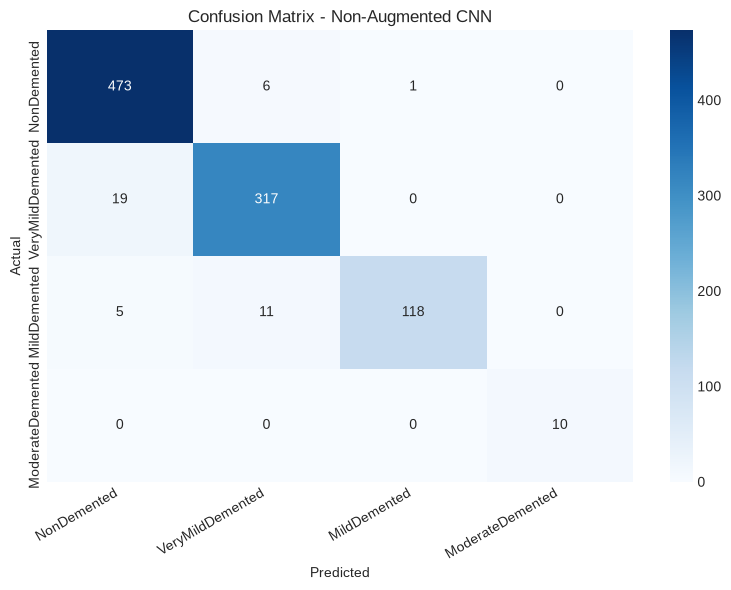

In [20]:
original_results = evaluate_model(
    original_model,
    criterion,
    test_loader,
    title='Non-Augmented CNN'
)

Augmented CNN
Loss     : 0.1329
Accuracy : 0.9427
Precision: 0.9438
Recall   : 0.9427
F1 Score : 0.9422


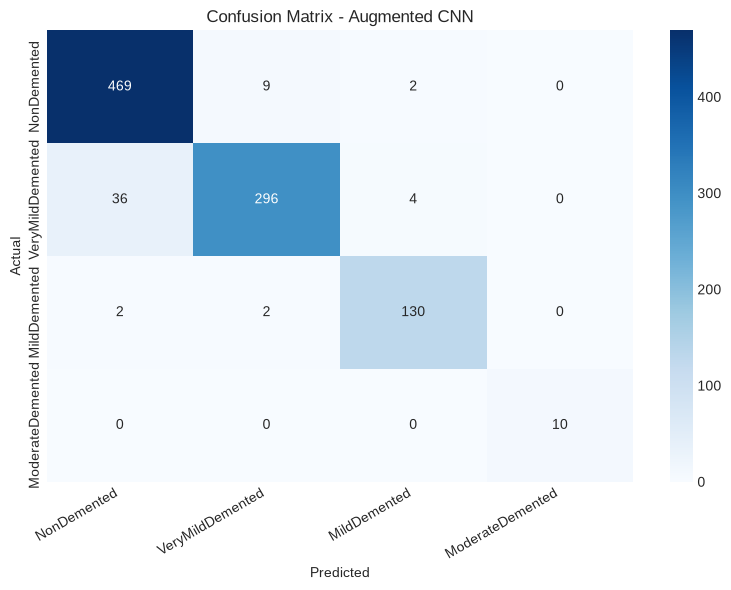

In [21]:
augmented_results = evaluate_model(
    augmented_model,
    criterion,
    test_loader,
    title='Augmented CNN'
)

,Test Loss,Accuracy,Precision,Recall,F1 Score
Model,,,,,
Non-Augmented CNN,0.1094,0.9562,0.9569,0.9562,0.9560
Augmented CNN,0.1329,0.9427,0.9438,0.9427,0.9422


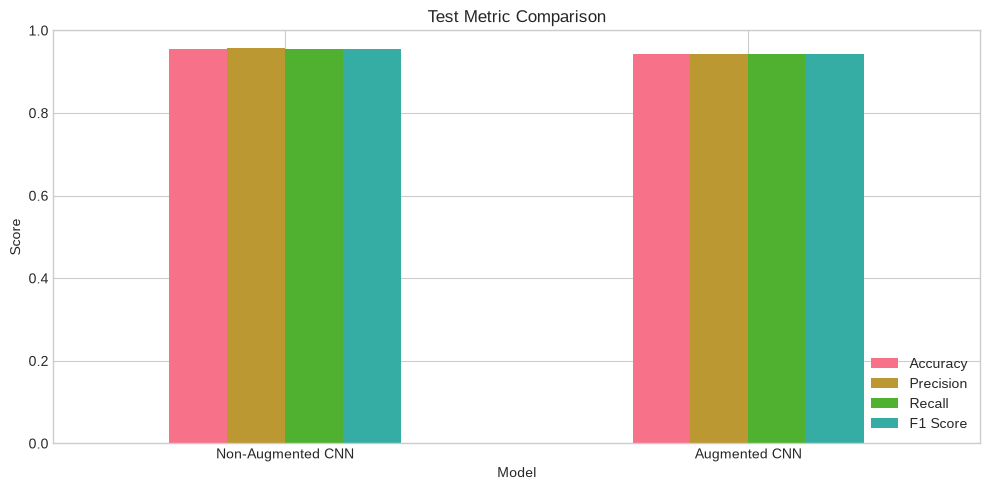

In [22]:
comparison = pd.DataFrame([
    {
        'Model': 'Non-Augmented CNN',
        'Test Loss': original_results['loss'],
        'Accuracy': original_results['accuracy'],
        'Precision': original_results['precision'],
        'Recall': original_results['recall'],
        'F1 Score': original_results['f1_score'],
    },
    {
        'Model': 'Augmented CNN',
        'Test Loss': augmented_results['loss'],
        'Accuracy': augmented_results['accuracy'],
        'Precision': augmented_results['precision'],
        'Recall': augmented_results['recall'],
        'F1 Score': augmented_results['f1_score'],
    },
]).set_index('Model')

display(comparison.round(4))

comparison[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(10, 5),
    ylim=(0, 1)
)
plt.title('Test Metric Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Result Interpretation

After running both experiments, compare the learning curves, test metrics and confusion matrices. In particular, inspect whether augmentation improves recognition of the less frequent disease stages and whether either model begins to overfit according to the validation curves.

The `ModerateDemented` class contains very few original images, so its validation and test results should be interpreted cautiously. A patient-level split would also be preferable if patient identifiers become available.